In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
# import geopandas as gpd
import pandas as pd
import seaborn as sns
from scipy.stats import qmc
from ipywidgets import IntProgress
import math as math

# importeren van ewatercycle
import ewatercycle
import ewatercycle.models
import ewatercycle.forcing

from ewatercycle_discharge import DischargeLocal

shape_file_area = 7.629080e+03 # in km^2

In [2]:
basin_name = "boven_suriname"

historical_start_date = "2019-01-01"
historical_end_date = "2024-12-31"
future_start_data = "2027-01-01"
future_end_data = "2099-12-31"

shapefile = Path.home() / "BEP-Julian" / "BEP-Julian" / "Suriname_Model" / "boven_suriname.shp"

forcing_route_CMIP = Path.home() / "BEP-Julian" / "BEP-Julian" / "Forcing" / "CMIP"

forcing_route = Path.home() / "BEP-Julian" / "BEP-Julian" / "Forcing" / "ERA5_SUR_2019_2024"/ "work" / "diagnostic" / "script" 

Eigen_model = Path.home() / "BEP-Julian" / "BEP-Julian" / "Suriname_Model" / "discharge_bmi"
# model_path_HBV = Path.home() / "tmp" / "HBV_model" / "CMIP"
# model_path_HBV.mkdir(exist_ok=True)

# gdf = gpd.read_file("estreams_cb_FR003882.shp")
# gdf = gdf.to_crs(epsg=2154)
# gdf["area_km2"] = gdf.geometry.area / 1e6  
# basin_area = gdf["area_km2"].sum()

In [3]:
# # Option one: Generate CMIP data
# cmip_dataset =  {
#    'project': 'CMIP6',
#    'activity': 'ScenarioMIP',
#    'exp': 'ssp245',              # veranderen per generatie CMIP data
#    'mip': 'day',
#    'dataset': 'MPI-ESM1-2-HR',
#    'ensemble': 'r1i1p1f1',
#    'institute': 'DKRZ',
#    'grid': 'gn'
# }

# cmip_historical =  {
#    'project': 'CMIP6',
#    'exp': 'historical',
#    'dataset': 'MPI-ESM1-2-HR',
#    "ensemble": 'r1i1p1f1',
#    'grid': 'gn'
# }

# ssp126_dir = forcing_route_CMIP / "SSP126_26-99"
# ssp245_dir = forcing_route_CMIP / "SSP245_26-99"
# ssp585_dir = forcing_route_CMIP / "SSP585_26-99"
# historical = forcing_route_CMIP / "historical"

# CMIP_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].generate(
#    dataset=cmip_dataset,        # veranderen per generatie CMIP data
#    start_time=historical_start_date+"T00:00:00Z",
#    end_time=historical_end_date+"T00:00:00Z",
#    shape=shapefile,
#    directory=historical,        # veranderen per generatie CMIP data
# )

In [4]:
# Option two: load generated data
# Load historical data
historic_location = forcing_route_CMIP / "historical" / "work" / "diagnostic" / "script" 
HIST = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=historic_location)

# Load SSP126 data
ssp126_location = forcing_route_CMIP / "SSP126_26-99" / "work" / "diagnostic" / "script" 
SSP126 = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=ssp126_location)

# Load SSP245 data
ssp245_location = forcing_route_CMIP / "SSP245_26-99" / "work" / "diagnostic" / "script" 
SSP245 = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=ssp245_location)

# Load SSP585 data
ssp585_location = forcing_route_CMIP / "SSP585_26-99" / "work" / "diagnostic" / "script" 
SSP585 = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=ssp585_location)

ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=forcing_route)
evap = ERA5_forcing.to_xarray()["evspsblpot"] #units: kg m^-2 s^-1 = mm/s, gesampled per dag
prec = ERA5_forcing.to_xarray()["pr"] #units: kg m^-2 s^-1 = mm/s, gesampled per dag

In [5]:
print(HIST)
print(SSP126)
print(SSP245)
print(SSP585)

start_time='2019-01-01T00:00:00Z' end_time='2024-12-31T00:00:00Z' directory=PosixPath('/home/julian/BEP-Julian/BEP-Julian/Forcing/CMIP/historical/work/diagnostic/script') shape=PosixPath('/home/julian/BEP-Julian/BEP-Julian/Forcing/CMIP/historical/work/diagnostic/script/boven_suriname.shp') filenames={'pr': 'CMIP6_MPI-ESM1-2-HR_day_ssp245_r1i1p1f1_pr_gn_2019-2024.nc', 'tas': 'CMIP6_MPI-ESM1-2-HR_day_ssp245_r1i1p1f1_tas_gn_2019-2024.nc', 'rsds': 'CMIP6_MPI-ESM1-2-HR_day_ssp245_r1i1p1f1_rsds_gn_2019-2024.nc', 'evspsblpot': 'Derived_Makkink_evspsblpot.nc'}
start_time='2027-01-01T00:00:00Z' end_time='2099-12-31T00:00:00Z' directory=PosixPath('/home/julian/BEP-Julian/BEP-Julian/Forcing/CMIP/SSP126_26-99/work/diagnostic/script') shape=PosixPath('/home/julian/BEP-Julian/BEP-Julian/Forcing/CMIP/SSP126_26-99/work/diagnostic/script/boven_suriname.shp') filenames={'pr': 'CMIP6_MPI-ESM1-2-HR_day_ssp126_r1i1p1f1_pr_gn_2027-2099.nc', 'tas': 'CMIP6_MPI-ESM1-2-HR_day_ssp126_r1i1p1f1_tas_gn_2027-2099.nc

In [6]:
forcing_list = [HIST, SSP126, SSP245, SSP585] 
output = []
years = []
params = [1.30978424, 0.39171679, 1.05045276]

for forcings in forcing_list:
    model = DischargeLocal(forcing=forcings)
    config_file, _ = model.setup(
        parameters=params, 
        cfg_dir = Eigen_model,
    )

    model.initialize(config_file)

    Q_m = []
    time = []
    
    while model.time < model.end_time:
        model.update()
        Q_m.append(model.get_value("Q")[0])
        time.append(pd.Timestamp(model.time_as_datetime))
        
    output.append(Q_m)
    years.append(time)
    
    del Q_m, time
    model.finalize()

In [7]:
historical_output = pd.Series(data=output[0], name="Historical", index=years[0])["2019-01-01":]
SSP126_output = pd.Series(data=output[1], name="SSP126", index=years[1])["2027-01-01":]
SSP245_output = pd.Series(data=output[2], name="SSP245", index=years[2])["2027-01-01":]
SSP585_output = pd.Series(data=output[3], name="SSP585", index=years[3])["2027-01-01":]

# Convert mm/d to m3/s
factor = shape_file_area / 86.4
historical_output *= factor
SSP126_output *= factor
SSP245_output *= factor
SSP585_output *= factor

In [8]:
parameter_test = [1.30978424, 0.39171679, 1.05045276]
model = DischargeLocal(forcing = ERA5_forcing)
config_file, _ = model.setup(parameters=parameter_test, cfg_dir=Eigen_model)

model.initialize(config_file)
Q_m = []
time = []

while model.time < model.end_time:
    model.update()
    Q_m.append(model.get_value("Q")[0])
    time.append(pd.Timestamp(model.time_as_datetime))

model.finalize()

/home/julian/BEP-Julian/BEP-Julian/Forcing/CMIP/historical/work/diagnostic/script/CMIP6_MPI-ESM1-2-HR_day_ssp245_r1i1p1f1_pr_gn_2019-2024.nc
/home/julian/BEP-Julian/BEP-Julian/Forcing/CMIP/historical/work/diagnostic/script/Derived_Makkink_evspsblpot.nc


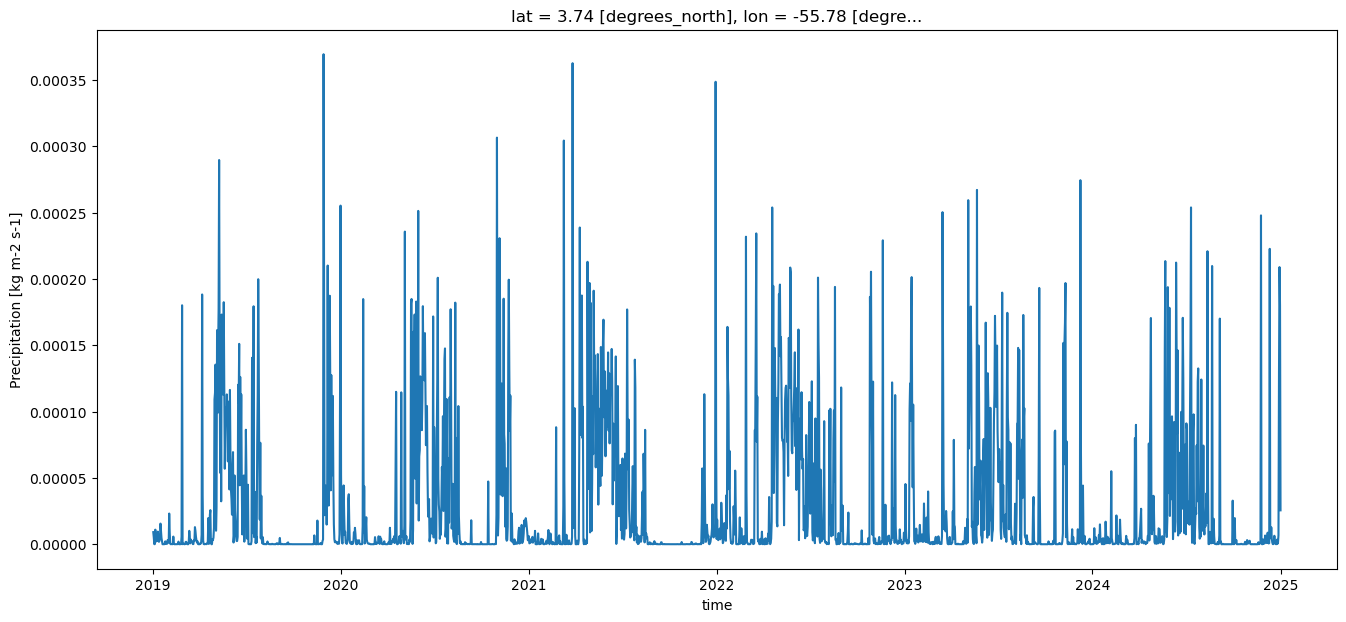

In [9]:
plt.figure(figsize=(16, 7))
print(HIST["pr"])
print(HIST["evspsblpot"])
# plt.plot(HIST.index, HIST["pr"])
# print(historical_output)
evap_hist = HIST.to_xarray()["evspsblpot"] #units: kg m^-2 s^-1 = mm/s, gesampled per dag
prec_hist = HIST.to_xarray()["pr"] #units: kg m^-2 s^-1 = mm/s, gesampled per dag
# print(evap_hist)
# print(prec_hist)
prec_hist.plot()

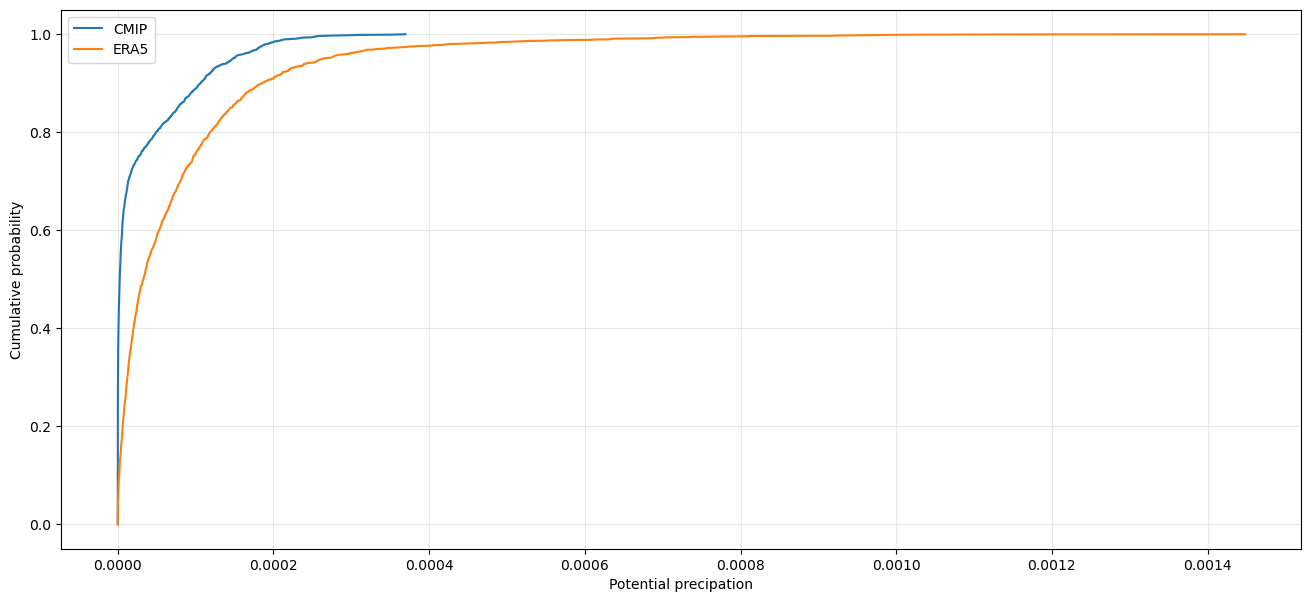

In [10]:
def ecdf(x):
    x = np.asarray(x)
    x = x[np.isfinite(x)]      # remove NaNs
    x = np.sort(x)
    y = np.arange(1, len(x)+1) / len(x)
    return x, y

x_cmip, y_cmip = ecdf(prec_hist)
x_era5, y_era5 = ecdf(prec)

plt.figure(figsize=(16, 7))

plt.plot(x_cmip, y_cmip, label='CMIP')
plt.plot(x_era5, y_era5, label='ERA5')

plt.xlabel('Potential precipation')
plt.ylabel('Cumulative probability')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [11]:
# Evaporation quantile mapping

# evap_hist_corr = evap_cmip * era5_e.mean() / cmip_hist_e.mean()
evap_hist_corr = evap_hist * evap.mean() / evap_hist.mean()

In [12]:
# test nummer 2

In [13]:
prec = prec.compute()
evap = evap.compute()

prec_hist = prec_hist.compute()
evap_hist = evap_hist.compute()

In [14]:
thr = 1e-7
era_wet = prec.values[prec.values > thr]

hist_wet = prec_hist.values[
    prec_hist.values > thr
]

In [15]:
q = np.linspace(0,1,1000)

era_q_pr = np.quantile(
    era_wet,
    q
)

hist_q_pr = np.quantile(
    hist_wet,
    q
)

era_q_evap = np.quantile(
    evap.values,
    q
)

hist_q_evap = np.quantile(
    evap_hist.values,
    q
)

In [16]:
pr = prec_hist.values.copy()

pr_corr = np.zeros_like(pr)

mask = pr > thr

pr_corr[mask] = np.interp(
    pr[mask],
    hist_q_pr,
    era_q_pr,
    left=era_q_pr[0],
    right=era_q_pr[-1]
)
prec_hist_corr = xr.DataArray(
    pr_corr,
    coords=prec_hist.coords,
    dims=prec_hist.dims,
    attrs=prec_hist.attrs,
)

In [17]:
ev = evap_hist.values.copy()

ev_corr = np.interp(
    ev,
    hist_q_evap,
    era_q_evap,
    left=era_q_evap[0],
    right=era_q_evap[-1]
)

evap_hist_corr = xr.DataArray(
    ev_corr,
    coords=evap_hist.coords,
    dims=evap_hist.dims,
    attrs=evap_hist.attrs,
)

In [18]:
ssp126_ds = SSP126.to_xarray()
pr126 = ssp126_ds["pr"].compute()
evap126 = ssp126_ds["evspsblpot"].compute()
pr126_np = pr126.values.copy()
pr126_corr = np.zeros_like(pr126_np)
mask = pr126_np > thr
pr126_corr[mask] = np.interp(pr126_np[mask], hist_q_pr,era_q_pr, left=era_q_pr[0], right = era_q_pr[-1])
evap126_corr = np.interp(evap126.values, hist_q_evap, era_q_evap, left=era_q_evap[0], right=era_q_evap[-1])

ssp245_ds = SSP245.to_xarray()
pr245 = ssp245_ds["pr"].compute()
evap245 = ssp245_ds["evspsblpot"].compute()
pr245_np = pr245.values.copy()
pr245_corr = np.zeros_like(pr245_np)
mask = pr245_np > thr
pr245_corr[mask] = np.interp(pr245_np[mask], hist_q_pr,era_q_pr, left=era_q_pr[0], right = era_q_pr[-1])
evap245_corr = np.interp(evap245.values, hist_q_evap, era_q_evap, left=era_q_evap[0], right=era_q_evap[-1])

ssp585_ds = SSP585.to_xarray()
pr585 = ssp585_ds["pr"].compute()
evap585 = ssp585_ds["evspsblpot"].compute()
pr585_np = pr585.values.copy()
pr585_corr = np.zeros_like(pr585_np)
mask = pr585_np > thr
pr585_corr[mask] = np.interp(pr585_np[mask], hist_q_pr,era_q_pr, left=era_q_pr[0], right = era_q_pr[-1])
evap585_corr = np.interp(evap585.values, hist_q_evap, era_q_evap, left=era_q_evap[0], right=era_q_evap[-1])

In [19]:
SSP126_corr_ds = SSP126.to_xarray().copy()
SSP126_corr_ds["pr"] = xr.DataArray( pr126_corr, coords=pr126.coords, dims=pr126.dims, attrs=pr126.attrs, )
SSP126_corr_ds["evspsblpot"] = xr.DataArray( evap126_corr, coords=evap126.coords, dims=evap126.dims, attrs=evap126.attrs,)

SSP245_corr_ds = SSP245.to_xarray().copy()
SSP245_corr_ds["pr"] = xr.DataArray( pr245_corr, coords=pr245.coords, dims=pr245.dims, attrs=pr245.attrs, )
SSP245_corr_ds["evspsblpot"] = xr.DataArray( evap245_corr, coords=evap245.coords, dims=evap245.dims, attrs=evap245.attrs,)

SSP585_corr_ds = SSP585.to_xarray().copy()
SSP585_corr_ds["pr"] = xr.DataArray( pr585_corr, coords=pr585.coords, dims=pr585.dims, attrs=pr585.attrs, )
SSP585_corr_ds["evspsblpot"] = xr.DataArray( evap585_corr, coords=evap585.coords, dims=evap585.dims, attrs=evap585.attrs,)

HIST_corr_ds = HIST.to_xarray().copy()
HIST_corr_ds["pr"] = xr.DataArray( prec_hist_corr, coords=prec_hist.coords, dims=prec_hist.dims, attrs=prec_hist.attrs, )
HIST_corr_ds["evspsblpot"] = xr.DataArray( evap_hist_corr, coords=evap_hist.coords, dims=evap_hist.dims, attrs=evap_hist.attrs,)

In [54]:
HIST_corr_ds.to_netcdf(
    historic_location / "forcing_biascorr.nc"
)
SSP126_corr_ds.to_netcdf(
    ssp126_location / "forcing_biascorr.nc"
)
SSP245_corr_ds.to_netcdf(
    ssp245_location / "forcing_biascorr.nc"
)
SSP585_corr_ds.to_netcdf(
    ssp585_location / "forcing_biascorr.nc"
)

HIST_corr = HIST.model_copy(deep=True)

SSP126_corr = SSP126.model_copy(deep=True)

SSP245_corr = SSP245.model_copy(deep=True)

SSP585_corr = SSP585.model_copy(deep=True)

In [55]:
print(HIST_corr.filenames)

{'pr': 'CMIP6_MPI-ESM1-2-HR_day_ssp245_r1i1p1f1_pr_gn_2019-2024.nc', 'tas': 'CMIP6_MPI-ESM1-2-HR_day_ssp245_r1i1p1f1_tas_gn_2019-2024.nc', 'rsds': 'CMIP6_MPI-ESM1-2-HR_day_ssp245_r1i1p1f1_rsds_gn_2019-2024.nc', 'evspsblpot': 'Derived_Makkink_evspsblpot.nc'}


In [56]:
HIST_corr.filenames["pr"] = "forcing_biascorr.nc"
HIST_corr.filenames["evspsblpot"] = "forcing_biascorr.nc"

SSP126_corr.filenames["pr"] = "forcing_biascorr.nc"
SSP126_corr.filenames["evspsblpot"] = "forcing_biascorr.nc"

SSP245_corr.filenames["pr"] = "forcing_biascorr.nc"
SSP245_corr.filenames["evspsblpot"] = "forcing_biascorr.nc"

SSP585_corr.filenames["pr"] = "forcing_biascorr.nc"
SSP585_corr.filenames["evspsblpot"] = "forcing_biascorr.nc"

In [61]:
print(HIST_corr)
print(HIST_corr.filenames)
test = HIST_corr.to_xarray()

print(test)

start_time='2019-01-01T00:00:00Z' end_time='2024-12-31T00:00:00Z' directory=PosixPath('/home/julian/BEP-Julian/BEP-Julian/Forcing/CMIP/historical/work/diagnostic/script') shape=PosixPath('/home/julian/BEP-Julian/BEP-Julian/Forcing/CMIP/historical/work/diagnostic/script/boven_suriname.shp') filenames={'pr': 'forcing_biascorr.nc', 'tas': 'CMIP6_MPI-ESM1-2-HR_day_ssp245_r1i1p1f1_tas_gn_2019-2024.nc', 'rsds': 'CMIP6_MPI-ESM1-2-HR_day_ssp245_r1i1p1f1_rsds_gn_2019-2024.nc', 'evspsblpot': 'forcing_biascorr.nc'}
{'pr': 'forcing_biascorr.nc', 'tas': 'CMIP6_MPI-ESM1-2-HR_day_ssp245_r1i1p1f1_tas_gn_2019-2024.nc', 'rsds': 'CMIP6_MPI-ESM1-2-HR_day_ssp245_r1i1p1f1_rsds_gn_2019-2024.nc', 'evspsblpot': 'forcing_biascorr.nc'}
<xarray.Dataset> Size: 61kB
Dimensions:     (time: 2192, bnds: 2)
Coordinates:
  * time        (time) datetime64[ns] 18kB 2019-01-01T12:00:00 ... 2024-12-31...
    lat         float64 8B 3.74
    lon         float64 8B -55.78
Dimensions without coordinates: bnds
Data variables:
  

In [62]:
forcing_list = [HIST_corr, SSP126_corr, SSP245_corr, SSP585_corr] 
output_corr = []
years_corr = []
params = [1.30978424, 0.39171679, 1.05045276]

for forcings in forcing_list:
    model = DischargeLocal(forcing=forcings)
    config_file, _ = model.setup(
        parameters=params, 
        cfg_dir = Eigen_model,
    )

    model.initialize(config_file)

    Q_m = []
    time = []
    
    while model.time < model.end_time:
        model.update()
        Q_m.append(model.get_value("Q")[0])
        time.append(pd.Timestamp(model.time_as_datetime))
        
    output_corr.append(Q_m)
    years_corr.append(time)
    
    del Q_m, time
    model.finalize()

In [63]:
historical_output = pd.Series(data=output_corr[0], name="Historical", index=years[0])["2019-01-01":]
SSP126_output = pd.Series(data=output_corr[1], name="SSP126", index=years[1])["2027-01-01":]
SSP245_output = pd.Series(data=output_corr[2], name="SSP245", index=years[2])["2027-01-01":]
SSP585_output = pd.Series(data=output_corr[3], name="SSP585", index=years[3])["2027-01-01":]

# Convert mm/d to m3/s
factor = shape_file_area / 86.4
historical_output *= factor
SSP126_output *= factor
SSP245_output *= factor
SSP585_output *= factor

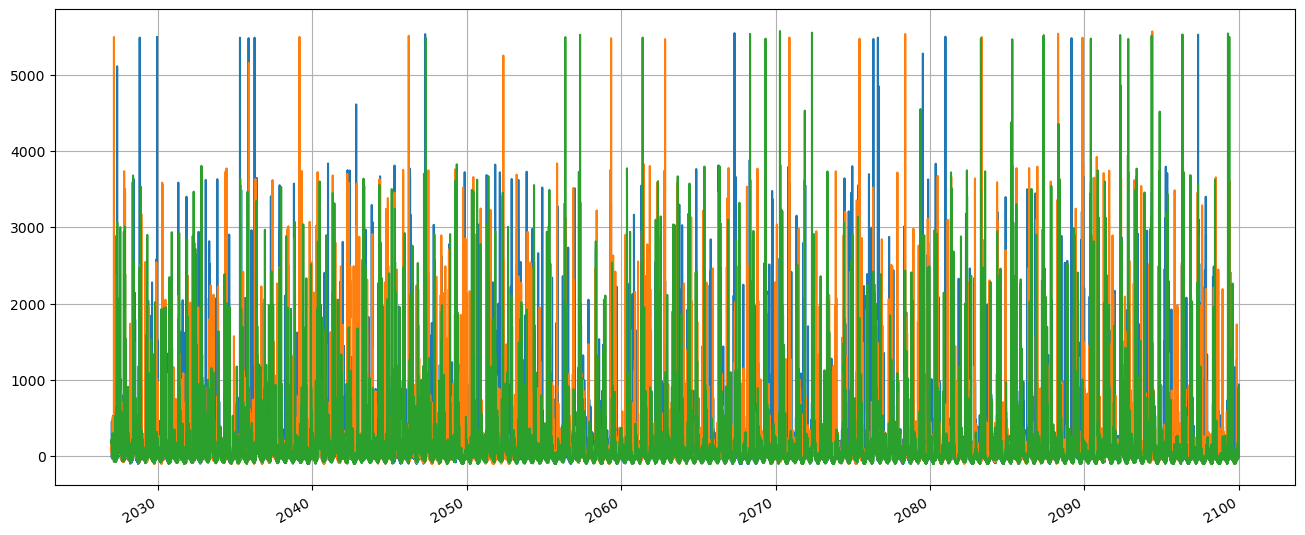

In [64]:
plt.figure(figsize=(16, 7))
SSP126_output.plot()
SSP245_output.plot()
SSP585_output.plot()
plt.grid();

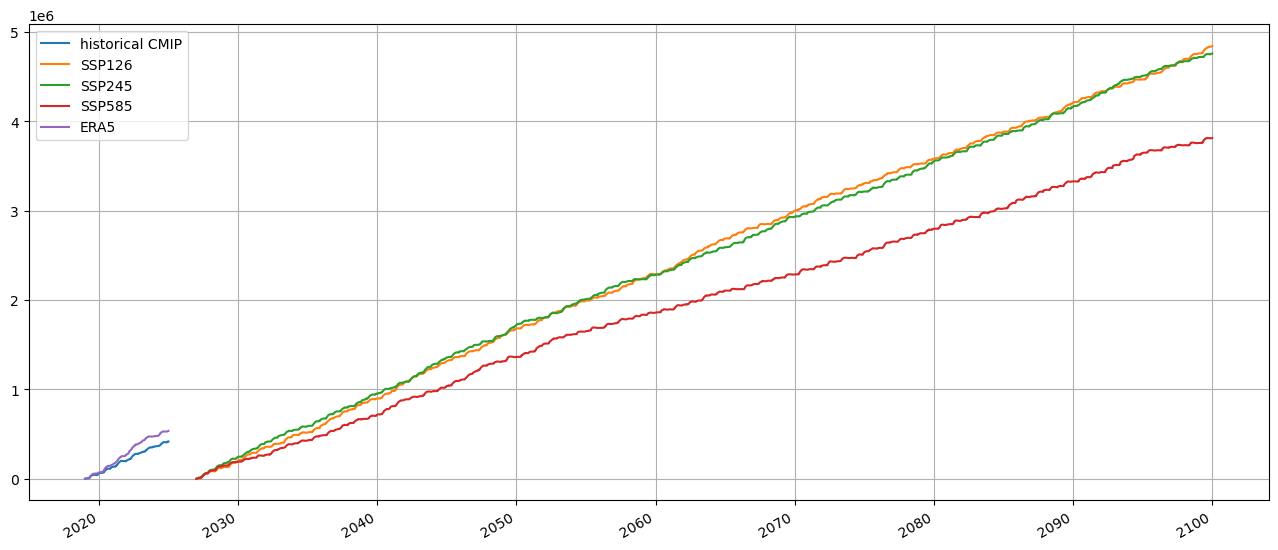

In [66]:
plt.figure(figsize=(16, 7))

historical_output_sum = historical_output.cumsum()
SSP126_output_sum = SSP126_output.cumsum()
SSP245_output_sum = SSP245_output.cumsum()
SSP585_output_sum = SSP585_output.cumsum()
model_output_m3s_test_sum = model_output_m3s_test.cumsum()

historical_output_sum.plot(label = "historical CMIP")
SSP126_output_sum.plot(label = "SSP126")
SSP245_output_sum.plot(label = "SSP245")
SSP585_output_sum.plot(label = "SSP585")
model_output_m3s_test_sum.plot(label = "ERA5")

plt.legend()
plt.grid();

In [20]:
# test nummer 1, geeft goede waardes en quantile mapping, alleen onbekend hoe dit te gebruiken is in de discharge_bmi

In [21]:
sec_per_day = 86400

prec_mmday      = prec# * sec_per_day
prec_hist_mmday = prec_hist# * sec_per_day
print(evap.attrs)
print(evap_hist.attrs)

{'standard_name': 'water_potential_evaporation_flux', 'units': 'kg m-2 s-1', 'long_name': 'potential evaporation'}
{'standard_name': 'water_potential_evaporation_flux', 'units': 'kg m-2 s-1', 'long_name': 'potential evaporation'}


In [22]:
from scipy.interpolate import PchipInterpolator
import numpy as np

era = prec_mmday.compute().values.ravel()
cmip = prec_hist_mmday.compute().values.ravel()

q = np.linspace(0,1,1000)

era_q  = np.quantile(era, q)
cmip_q = np.quantile(cmip, q)

qm_prec = PchipInterpolator(
    cmip_q,
    era_q,
    extrapolate=True
)
prec_corr = qm_prec(prec_hist_mmday)
prec_corr = np.maximum(prec_corr,0)

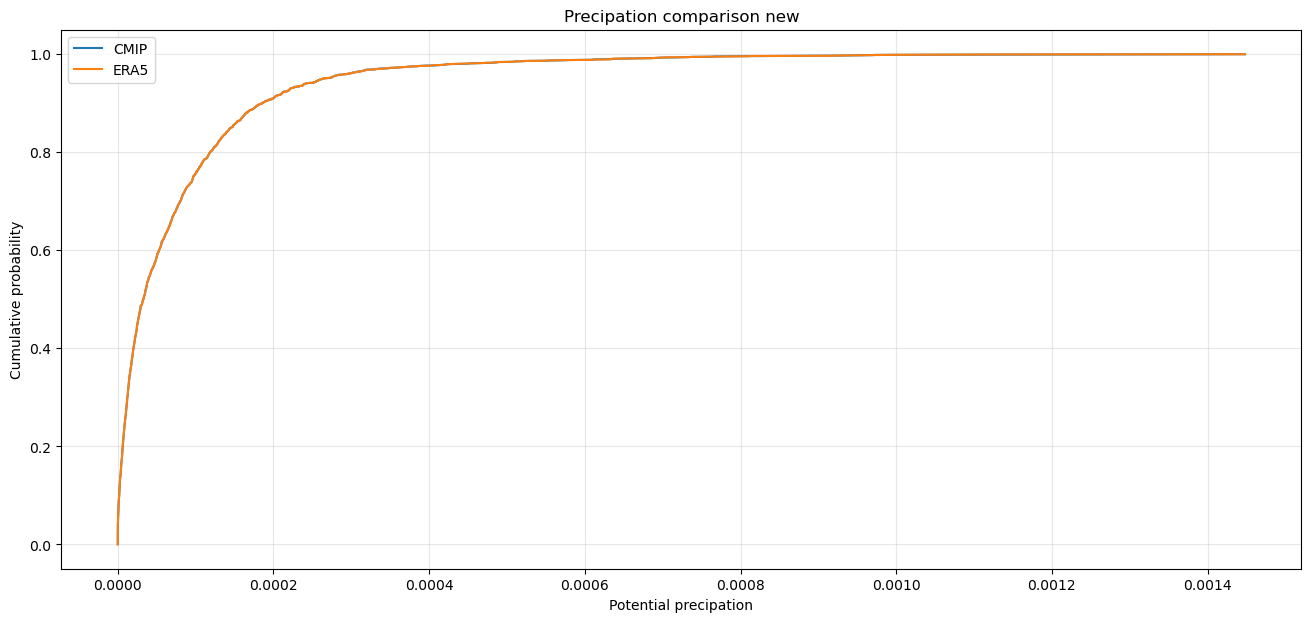

In [23]:
def ecdf(x):
    x = np.asarray(x)
    x = x[np.isfinite(x)]      # remove NaNs
    x = np.sort(x)
    y = np.arange(1, len(x)+1) / len(x)
    return x, y

x_cmip, y_cmip = ecdf(prec_corr)
x_era5, y_era5 = ecdf(prec)

plt.figure(figsize=(16, 7))

plt.plot(x_cmip, y_cmip, label='CMIP')
plt.plot(x_era5, y_era5, label='ERA5')

plt.xlabel('Potential precipation')
plt.ylabel('Cumulative probability')
plt.title("Precipation comparison new")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

[0.00006863 0.00004997 0.00000619 ... 0.00055457 0.0003482  0.0000965 ]


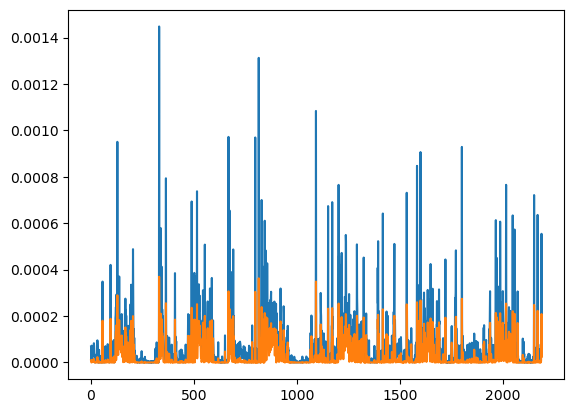

In [52]:
plt.plot(prec_corr)
plt.plot(prec_hist)
print(prec_corr)
# print(prec_hist)
miep = (prec_corr/prec_hist).values

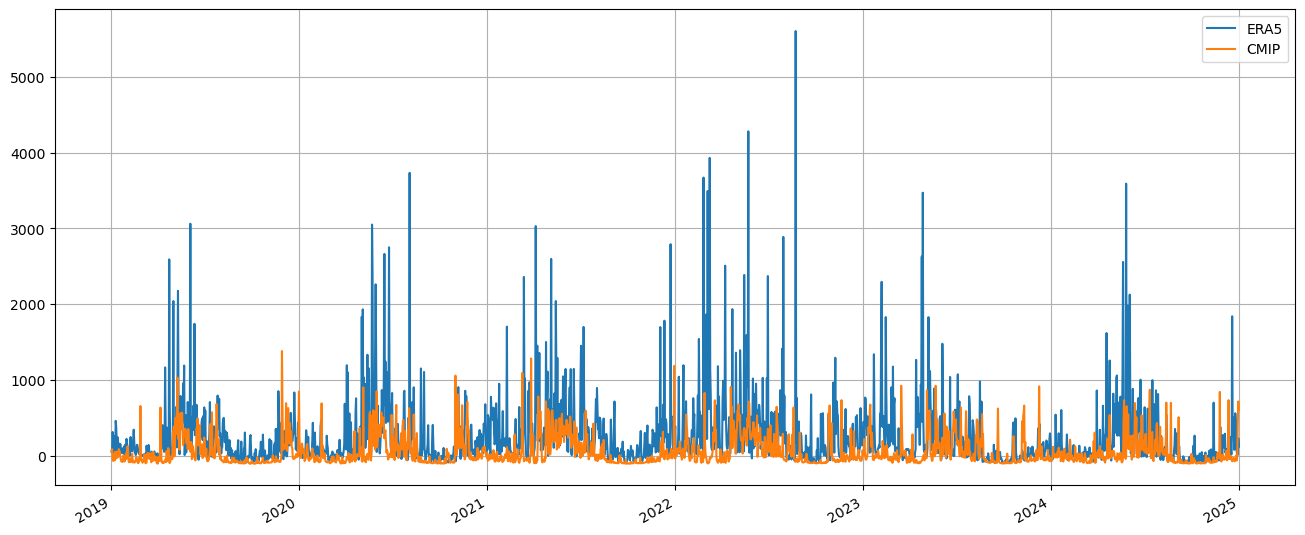

In [25]:
# vergelijken
plt.figure(figsize=(16, 7))
model_output_mmday = pd.Series(data=Q_m, name="Modelled discharge", index=time)
model_output_m3s_test = model_output_mmday * shape_file_area * 1000 / 86400

model_output_m3s_test.plot(label = "ERA5")
# print(historical_output)
historical_output.plot(label = "CMIP")
plt.legend()
plt.grid()

In [26]:
# einde test nummer 1

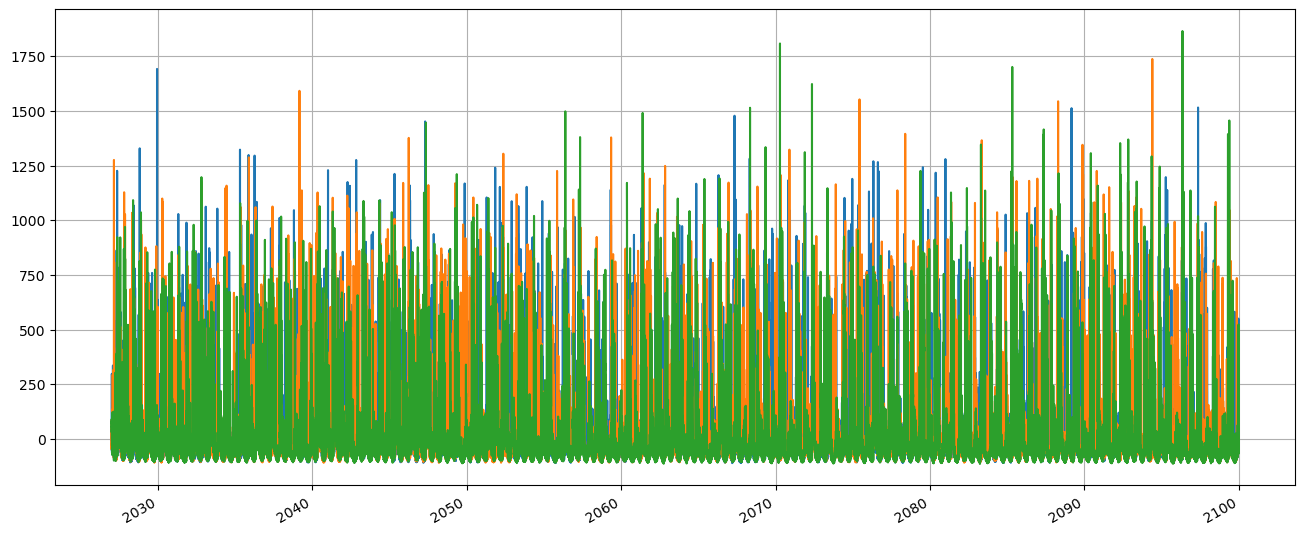

In [27]:
plt.figure(figsize=(16, 7))
SSP126_output.plot()
SSP245_output.plot()
SSP585_output.plot()
plt.grid();

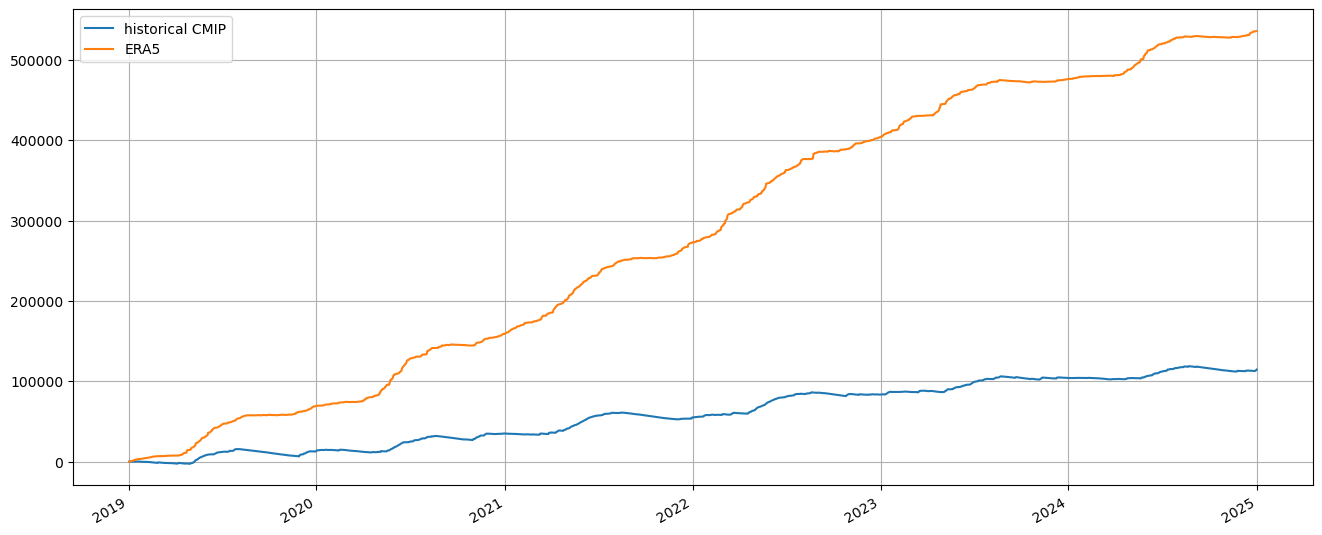

In [28]:
plt.figure(figsize=(16, 7))

historical_output_sum = historical_output.cumsum()
SSP126_output_sum = SSP126_output.cumsum()
SSP245_output_sum = SSP245_output.cumsum()
SSP585_output_sum = SSP585_output.cumsum()
model_output_m3s_test_sum = model_output_m3s_test.cumsum()

historical_output_sum.plot(label = "historical CMIP")
# SSP126_output_sum.plot(label = "SSP126")
# SSP245_output_sum.plot(label = "SSP245")
# SSP585_output_sum.plot(label = "SSP585")
model_output_m3s_test_sum.plot(label = "ERA5")

plt.legend()
plt.grid();

In [29]:
def level(Qin, Qout, ERA5_forcing, A, L0):
    # Qin is array met discharge van rivier in meer, gebaseerd op E en P en dagelijks [m^3/s]
    # Qout is een standaard baseflow uit het meer [m^3/s]
    # E is verdampingsdata van ERA5, dagelijks [mm/s]
    # A is oppervlakte meer [km^2]
    # L0 is een gegeven begin hoogte [m]
    # L0 moet handmatig worden ingevoerd omdat in de toekomst niet zeker is hoe hoog het meer gaat staan op het beginpunt van de forcing data
    
    dt = 3600*24
    E = ERA5_forcing.to_xarray()["evspsblpot"] /1000 #* dt
    L = np.zeros(len(Qin))
    L[0] = L0
    A = A * 10**6
    
    for i in range(len(Qin)-1):
        dL = ((Qin.iloc[i] - Qout) / A) - E[i]
        L[i+1] = L[i] + dL*dt 
        if L[i+1] > 48.5:
            L[i+1] = 48.5
    return L

In [30]:
Q_out = 200
A = 1020
L0 = 46.5

a = level(historical_output, Q_out, HIST, A, L0)
print(a)
print(len(a))

[46.5        46.48667848 46.47597247 ...  9.84352301  9.8642278
  9.90507537]
2191


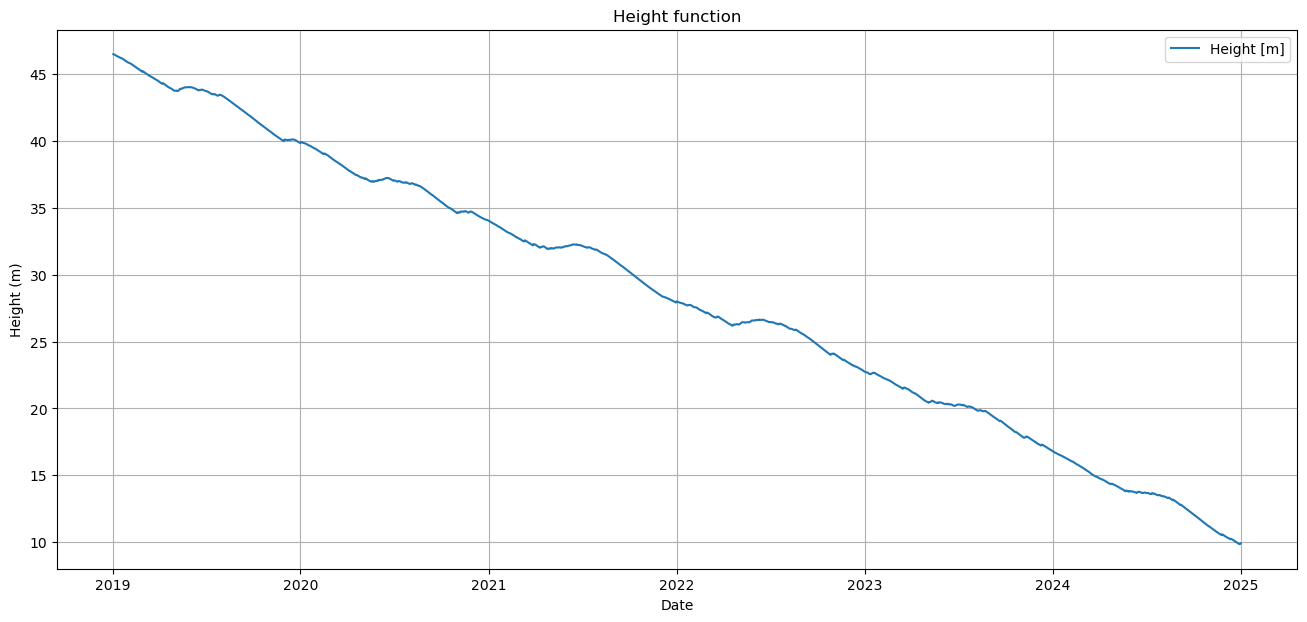

In [31]:
plt.figure(figsize=(16, 7))
plt.plot(historical_output.index, a, label = "Height [m]")

plt.xlabel("Date")
plt.ylabel("Height (m)")
plt.title("Height function")
plt.legend()
plt.grid(True)
plt.show()

np.set_printoptions(suppress=True)